In [1]:
import pandas as pd

In [6]:
df = pd.read_csv("Steel_industry_data.csv")

In [5]:
#Define X and y for ML model

In [7]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [11]:
#Target is Usage in kWh
y=df["Usage_kWh"]

In [9]:
print(y)

0        3.17
1        4.00
2        3.24
3        3.31
4        3.82
         ... 
35035    3.85
35036    3.74
35037    3.78
35038    3.78
35039    3.67
Name: Usage_kWh, Length: 35040, dtype: float64


In [12]:
features = [
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM"
    ]

In [19]:
#defining features for prediction

In [14]:
X = df[features]

In [15]:
print(X)

       Lagging_Current_Reactive.Power_kVarh  \
0                                      2.95   
1                                      4.46   
2                                      3.28   
3                                      3.56   
4                                      4.50   
...                                     ...   
35035                                  4.86   
35036                                  3.74   
35037                                  3.17   
35038                                  3.06   
35039                                  3.02   

       Leading_Current_Reactive_Power_kVarh  Lagging_Current_Power_Factor  \
0                                      0.00                         73.21   
1                                      0.00                         66.77   
2                                      0.00                         70.28   
3                                      0.00                         68.09   
4                                      0.00       

In [18]:
#train/test split 
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [20]:
#creating baseline model (avg value)
import numpy as np

In [21]:
baseline_pred = np.full(
    len(y_test),
    y_train.mean()
)

In [24]:
#training the ML model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[1.48,0.3 ,0.7 ,0.38,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh','Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor','NSM']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-84.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [25]:
#now we apply the ML model to the observations the model did not train on
pred = model.predict(X_test)

In [26]:
#now we evaluate the ML model metrics (R2, MAE, RMSE)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error (y_test, pred)

rmse = np.sqrt(
    mean_squared_error(y_test, pred)
)

r2 = r2_score(y_test,pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 6.989460894160898
RMSE: 10.113855768750106
R2: 0.9100131359176624


In [28]:
#Now we compare our ML model with our baseline (mean value)
baseline_mae = mean_absolute_error (baseline_pred, y_test)
baseline_rmse = np.sqrt(
    mean_squared_error(baseline_pred,y_test)
)
baseline_r2 = r2_score(baseline_pred,y_test)

print("MAE_Baseline:", baseline_mae)
print("RMSE_Baseline:", baseline_rmse)
print("R2_Baseline:", baseline_r2)

MAE_Baseline: 28.801618233760244
RMSE_Baseline: 33.71908130625841
R2_Baseline: -2.252013862276526e+31


In [29]:
#summarizing the difference between ML model and baseline
results = pd.DataFrame ({
    "Model": [
        "Mean baseline",
        "Linear regression",
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE":[
        baseline_rmse,
        rmse
    ],
    "R2":[
        baseline_r2,
        r2
    ]
})

In [30]:
print(results)

               Model        MAE       RMSE            R2
0      Mean baseline  28.801618  33.719081 -2.252014e+31
1  Linear regression   6.989461  10.113856  9.100131e-01


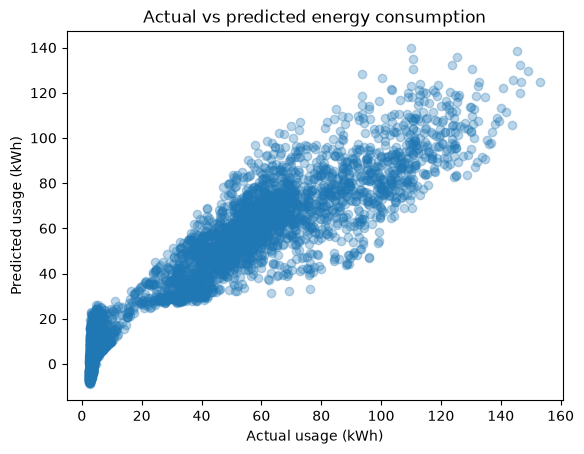

In [31]:
#visualizing predictions
import matplotlib.pyplot as plt

plt.scatter(
    y_test,
    pred,
    alpha = 0.3
)

plt.xlabel("Actual usage (kWh)")
plt.ylabel("Predicted usage (kWh)")
plt.title("Actual vs predicted energy consumption")

plt.show()

## Model interpretation
A multiple linear regression model was trained to predict industrial energy consumption from electrical process variables.
The data were divided into training and test subsets so that the model performance could be evaluated on observations not used during fitting.
Model performance was evaluated using MAE, RMSE, and R2 and compared with a mean-prediction baseline.
The ML model predicts accurately the energy consumption, with model metrics showing an R2 of 0.91 and MAE/RMSE much smaller than the baseline cases. 